# Movie Recommender System

Build a beginner-friendly **collaborative filtering** system from user ratings. We will explore the data, hold out one rating per user, predict those ratings from similar users, and produce two kinds of recommendations.

**Dataset:** local ratings and movie metadata included in `data/movielens/`.

All code, explanations, and data used by this project are included in this repository.

## 1. Set up the experiment

Google Colab already includes these packages. Locally, run `python -m pip install numpy pandas matplotlib seaborn scikit-learn`. The seed makes the fallback data and holdout split repeatable.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")

## 2. Load ratings and movie titles

The local `ratings.csv` and `movies.csv` files provide all user-item data required by this recommender.

In [2]:
DATA_DIR = Path("data/movielens") if Path("data/movielens").exists() else Path("../data/movielens")
if not DATA_DIR.exists():
    raise FileNotFoundError("Run this notebook from the repository root so data/ is available.")

def make_fallback_data(random_generator):
    movie_rows = [
        (1, "Orbit Run", "Adventure|Sci-Fi"),
        (2, "Red Planet", "Drama|Sci-Fi"),
        (3, "Tomorrow Station", "Sci-Fi|Thriller"),
        (4, "Laugh Track", "Comedy"),
        (5, "Weekend Mixup", "Comedy|Romance"),
        (6, "Office Escape", "Comedy"),
        (7, "Quiet River", "Drama"),
        (8, "Last Letter", "Drama|Romance"),
        (9, "City Lights Again", "Drama"),
        (10, "Hidden Trail", "Adventure|Mystery"),
        (11, "Summit Road", "Action|Adventure"),
        (12, "Jungle Signal", "Adventure|Mystery"),
        (13, "Heartlines", "Romance"),
        (14, "Summer Promise", "Comedy|Romance"),
        (15, "Night Detective", "Mystery|Thriller"),
    ]
    fallback_movies = pd.DataFrame(movie_rows, columns=["movieId", "title", "genres"])
    favorite_genres = ["Sci-Fi", "Comedy", "Drama", "Adventure", "Romance"]
    rating_rows = []

    for user_id in range(1, 61):
        favorite = favorite_genres[(user_id - 1) % len(favorite_genres)]
        watched_ids = random_generator.choice(
            fallback_movies["movieId"], size=10, replace=False
        )
        for movie_id in watched_ids:
            genres = fallback_movies.loc[
                fallback_movies["movieId"] == movie_id, "genres"
            ].iloc[0]
            center = 4.3 if favorite in genres else 2.8
            noisy_rating = center + random_generator.normal(0, 0.55)
            rating = np.clip(np.round(noisy_rating * 2) / 2, 0.5, 5.0)
            rating_rows.append((user_id, int(movie_id), float(rating), 0))

    fallback_ratings = pd.DataFrame(
        rating_rows, columns=["userId", "movieId", "rating", "timestamp"]
    )
    return fallback_ratings, fallback_movies

ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
source_name = "local recommender dataset"

print(
    f"Source: {source_name} | {len(ratings):,} ratings | "
    f"{ratings['userId'].nunique():,} users | {movies['movieId'].nunique():,} movies"
)
display(ratings.head())
display(movies.head())

Source: local recommender dataset | 5,400 ratings | 300 users | 30 movies


,userId,movieId,rating,timestamp
0,1,19,5.0,0
1,1,27,2.5,0
2,1,4,2.5,0
3,1,2,4.0,0
4,1,11,4.5,0


,movieId,title,genres
0,1,Orbit Run,Adventure|Sci-Fi
1,2,Red Planet,Drama|Sci-Fi
2,3,Tomorrow Station,Sci-Fi|Thriller
3,4,Laugh Track,Comedy
4,5,Weekend Mixup,Comedy|Romance


## 3. Join and summarize the data

Ratings use numeric movie IDs. Joining the title table makes the rows readable, and a per-movie summary reveals why rating count matters alongside the average.

In [3]:
data = ratings.merge(movies, on="movieId", how="left", validate="many_to_one")
movie_summary = (
    data.groupby(["movieId", "title"], as_index=False)
    .agg(mean_rating=("rating", "mean"), rating_count=("rating", "size"))
)

display(data.head())
display(movie_summary.sort_values("rating_count", ascending=False).head(10))

,userId,movieId,rating,timestamp,title,genres
0,1,19,5.0,0,Signal Beyond,Sci-Fi|Mystery
1,1,27,2.5,0,Bright Side Street,Comedy
2,1,4,2.5,0,Laugh Track,Comedy
3,1,2,4.0,0,Red Planet,Drama|Sci-Fi
4,1,11,4.5,0,Summit Road,Action|Adventure


,movieId,title,mean_rating,rating_count
20,21,Wild Circuit,2.987179,195
25,26,Tidal Code,3.374346,191
11,12,Jungle Signal,3.384817,191
0,1,Orbit Run,3.171053,190
5,6,Office Escape,3.026455,189
21,22,Midnight Recipe,3.193548,186
9,10,Hidden Trail,3.359459,185
24,25,Autumn Postcard,3.369565,184
7,8,Last Letter,3.459239,184
10,11,Summit Road,2.940217,184


## 4. Explore ratings and popularity

The first chart shows how people use the rating scale. The second shows the most-rated titles; popular movies usually provide more reliable similarity estimates.

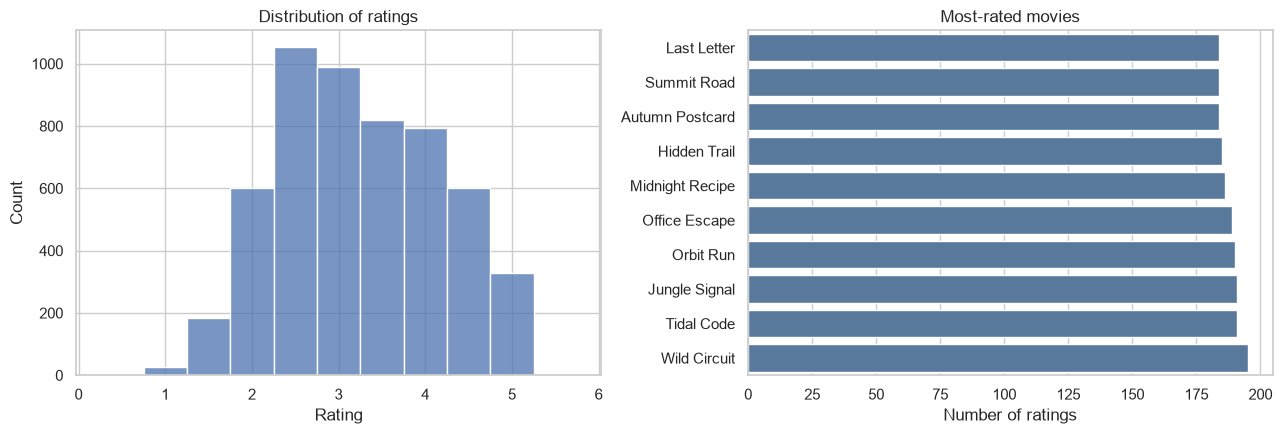

In [4]:
most_rated = movie_summary.nlargest(10, "rating_count").sort_values("rating_count")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(ratings["rating"], bins=np.arange(0.25, 5.76, 0.5), ax=axes[0])
axes[0].set(title="Distribution of ratings", xlabel="Rating")

sns.barplot(data=most_rated, x="rating_count", y="title", ax=axes[1], color="#4c78a8")
axes[1].set(title="Most-rated movies", xlabel="Number of ratings", ylabel="")

plt.tight_layout()
plt.show()

## 5. Hide one rating from each active user

For every user with at least five ratings, we hide one random rating. The model sees the remaining history and must estimate the hidden value—an easy-to-understand offline test.

In [5]:
ratings_per_user = ratings.groupby("userId").size()
eligible_users = ratings_per_user[ratings_per_user >= 5].index
eligible_rows = ratings[ratings["userId"].isin(eligible_users)]
test_indices = (
    eligible_rows.groupby("userId", group_keys=False)
    .sample(n=1, random_state=SEED)
    .index
)

train_ratings = ratings.drop(index=test_indices).reset_index(drop=True)
test_ratings = ratings.loc[test_indices].reset_index(drop=True)
print(f"Training ratings: {len(train_ratings):,} | Hidden ratings: {len(test_ratings):,}")

Training ratings: 5,100 | Hidden ratings: 300


## 6. Build a user-user collaborative filter

Rows are users, columns are movies, and missing entries mean “not rated.” We subtract each user's average before cosine similarity, then predict from the closest users who rated the target movie.

In [6]:
user_item = train_ratings.pivot_table(
    index="userId", columns="movieId", values="rating"
)
user_means = user_item.mean(axis=1)
centered = user_item.sub(user_means, axis=0).fillna(0)
user_similarity = pd.DataFrame(
    cosine_similarity(centered),
    index=user_item.index,
    columns=user_item.index,
)
for user_id in user_similarity.index:
    user_similarity.loc[user_id, user_id] = 0.0
global_mean = float(train_ratings["rating"].mean())

def predict_rating(user_id, movie_id, k=30):
    baseline = float(user_means.get(user_id, global_mean))
    if user_id not in user_item.index or movie_id not in user_item.columns:
        return float(np.clip(baseline, 0.5, 5.0))

    neighbor_ratings = user_item[movie_id].dropna().drop(index=user_id, errors="ignore")
    if neighbor_ratings.empty:
        return float(np.clip(baseline, 0.5, 5.0))

    similarities = user_similarity.loc[user_id, neighbor_ratings.index]
    neighbor_ids = similarities.abs().nlargest(k).index
    selected_similarities = similarities.loc[neighbor_ids]
    denominator = selected_similarities.abs().sum()
    if denominator < 1e-12:
        return float(np.clip(baseline, 0.5, 5.0))

    deviations = neighbor_ratings.loc[neighbor_ids] - user_means.loc[neighbor_ids]
    estimate = baseline + np.dot(selected_similarities, deviations) / denominator
    return float(np.clip(estimate, 0.5, 5.0))

print(f"User-item matrix: {user_item.shape[0]:,} users × {user_item.shape[1]:,} movies")

User-item matrix: 300 users × 30 movies


## 7. Evaluate hidden-rating predictions

MAE is the average absolute miss in rating points; RMSE penalizes large misses more. We also print a global-average baseline so the recommender has a simple comparison. Lower is better.

Collaborative-filter MAE: 0.548
Collaborative-filter RMSE: 0.680
Global-average baseline MAE: 0.763


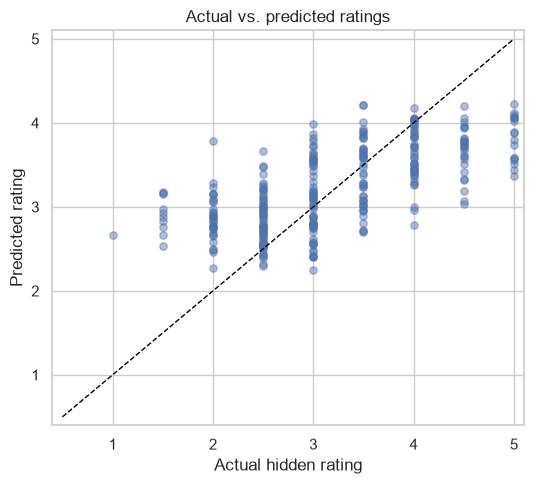

In [7]:
actual = test_ratings["rating"].to_numpy()
predicted = np.array([
    predict_rating(row.userId, row.movieId)
    for row in test_ratings.itertuples(index=False)
])
baseline_predicted = np.full(len(actual), global_mean)

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
baseline_mae = mean_absolute_error(actual, baseline_predicted)
print(f"Collaborative-filter MAE: {mae:.3f}")
print(f"Collaborative-filter RMSE: {rmse:.3f}")
print(f"Global-average baseline MAE: {baseline_mae:.3f}")

plt.figure(figsize=(5.5, 5))
plt.scatter(actual, predicted, alpha=0.45, s=28)
plt.plot([0.5, 5], [0.5, 5], "--", color="black", linewidth=1)
plt.xlim(0.4, 5.1)
plt.ylim(0.4, 5.1)
plt.xlabel("Actual hidden rating")
plt.ylabel("Predicted rating")
plt.title("Actual vs. predicted ratings")
plt.tight_layout()
plt.show()

## 8. Recommend unseen movies for one user

We score movies the user has not rated and keep titles with enough training ratings. Support filtering avoids ranking a movie from only one or two opinions.

In [8]:
movie_support = train_ratings.groupby("movieId").size()
minimum_support = 10 if train_ratings["userId"].nunique() >= 100 else 3
supported_movie_ids = movie_support[movie_support >= minimum_support].index

def recommend_for_user(user_id, top_n=8):
    if user_id not in user_item.index:
        raise ValueError(f"Unknown user ID: {user_id}")
    seen = set(train_ratings.loc[train_ratings["userId"] == user_id, "movieId"])
    candidates = [movie_id for movie_id in supported_movie_ids if movie_id not in seen]
    scores = pd.DataFrame({
        "movieId": candidates,
        "predicted_rating": [predict_rating(user_id, movie_id) for movie_id in candidates],
    })
    return (
        scores.merge(movies, on="movieId", how="left")
        .sort_values(["predicted_rating", "title"], ascending=[False, True])
        .head(top_n)[["title", "genres", "predicted_rating"]]
        .reset_index(drop=True)
    )

demo_user = int(train_ratings.groupby("userId").size().idxmax())
print(f"Recommendations for user {demo_user}:")
display(recommend_for_user(demo_user).round({"predicted_rating": 2}))

Recommendations for user 1:


,title,genres,predicted_rating
0,Orbit Run,Adventure|Sci-Fi,4.04
1,Tidal Code,Thriller|Sci-Fi,3.83
2,Mosaic Forest,Adventure|Drama,3.82
3,Wild Circuit,Action|Sci-Fi,3.68
4,Signal Beyond,Sci-Fi|Mystery,3.52
5,Jungle Signal,Adventure|Mystery,3.47
6,Parallel Weekend,Comedy|Sci-Fi,3.35
7,Quiet River,Drama,3.21


## 9. Find movies with similar audience ratings

Like the reference project, we can correlate one movie's rating column with every other movie. `common_raters` and shrinkage stop tiny overlaps from looking perfect.

In [9]:
def similar_movies(title, top_n=8, min_common=10):
    matches = movies.loc[movies["title"].str.casefold() == title.casefold()]
    if matches.empty:
        raise ValueError(f"Movie not found: {title}")
    anchor_id = int(matches.iloc[0]["movieId"])
    if anchor_id not in user_item.columns:
        raise ValueError("This movie has no training ratings.")

    anchor_ratings = user_item[anchor_id]
    correlations = user_item.corrwith(anchor_ratings)
    common_raters = user_item.notna().mul(anchor_ratings.notna(), axis=0).sum(axis=0)
    results = pd.DataFrame({
        "movieId": correlations.index,
        "correlation": correlations.values,
        "common_raters": common_raters.reindex(correlations.index).values,
    })
    results = results[
        (results["movieId"] != anchor_id)
        & (results["common_raters"] >= min_common)
        & results["correlation"].notna()
    ].copy()
    results["similarity_score"] = (
        results["correlation"] * results["common_raters"]
        / (results["common_raters"] + 10)
    )
    return (
        results.merge(movies, on="movieId", how="left")
        .sort_values("similarity_score", ascending=False)
        .head(top_n)[["title", "genres", "common_raters", "similarity_score"]]
        .reset_index(drop=True)
    )

available_titles = set(movies["title"])
anchor_title = (
    "Toy Story (1995)"
    if "Toy Story (1995)" in available_titles
    else most_rated.iloc[-1]["title"]
)
minimum_common = 10 if train_ratings["userId"].nunique() >= 100 else 3
print(f"Movies similar to {anchor_title!r}:")
display(similar_movies(anchor_title, min_common=minimum_common).round({"similarity_score": 3}))

Movies similar to 'Wild Circuit':


,title,genres,common_raters,similarity_score
0,Nova Harbor,Sci-Fi|Adventure,103,0.485
1,Orbit Run,Adventure|Sci-Fi,106,0.451
2,Tidal Code,Thriller|Sci-Fi,101,0.402
3,Red Planet,Drama|Sci-Fi,96,0.374
4,Parallel Weekend,Comedy|Sci-Fi,100,0.363
5,Tomorrow Station,Sci-Fi|Thriller,107,0.328
6,Signal Beyond,Sci-Fi|Mystery,97,0.269
7,Heartlines,Romance,99,0.206


## What the numbers do not tell us

Offline error is not the same as a delightful recommendation. Popularity bias, sparse histories, new users, new movies, and changing taste all matter. A real system should test ranking metrics such as Precision@K, add content features, protect privacy, and validate suggestions with users.

To use the older MovieLens files found in many tutorials, adapt the load cell so the final tables still contain `userId`, `movieId`, `rating`, `title`, and optionally `genres`; the remaining cells can stay the same.